# Retail Sales Data Analysis (EDA)

This project performs exploratory data analysis on a retail dataset to find patterns, trends, and business insights.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("C:/Users/Administrator/Downloads/retail_sales_dataset.csv")
df.head()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
# Shape
print("Shape:", df.shape)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1000, 9)

Data Types:
 Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing Values:
 Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [3]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

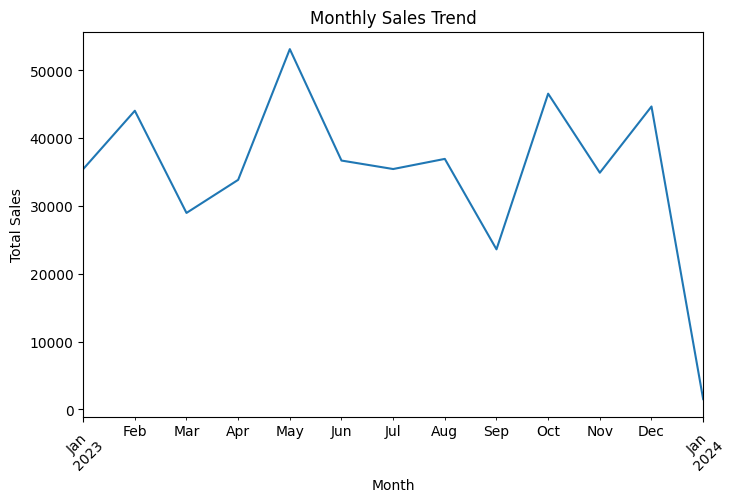

In [5]:
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

monthly_sales.plot(kind='line', figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# Observation: Monthly Sales Trend

- Sales are not constant and keep changing every month.
- Some months show higher sales compared to others.
- There are peak months where sales increase significantly.
- A sudden drop in the last month may indicate incomplete data.

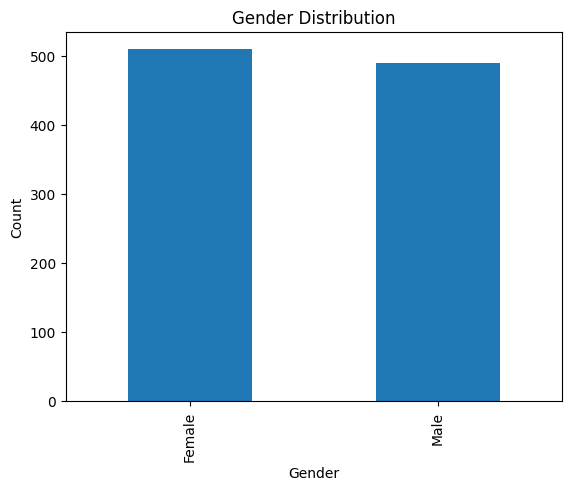

In [6]:
df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Observation: Gender Distribution

- The number of male and female customers is almost similar.
- No single gender dominates the dataset.

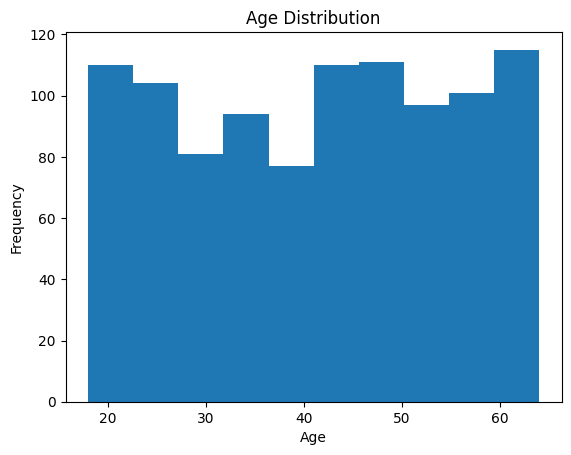

In [7]:
plt.hist(df['Age'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Observation: Age Distribution

- Most customers fall between the age of 30 to 55.
- Very few customers are below 20 or above 60.

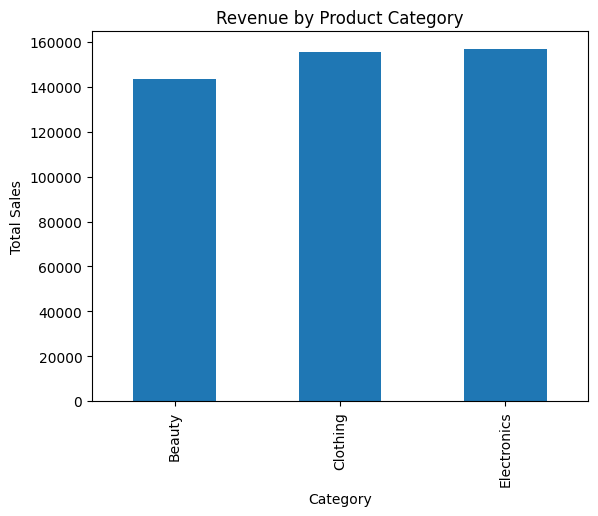

In [8]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

# Observation: Product Category Sales

- Some product categories generate more revenue than others.
- A few categories dominate overall sales.

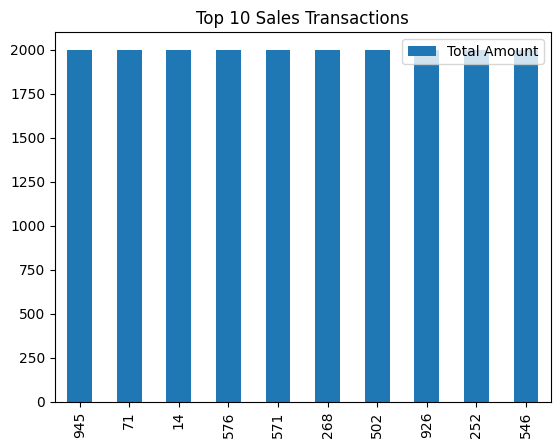

In [9]:
top_sales = df.sort_values(by='Total Amount', ascending=False).head(10)

top_sales[['Product Category', 'Total Amount']].plot(kind='bar')
plt.title("Top 10 Sales Transactions")
plt.show()

# Observation: Top Sales Transactions

- A small number of transactions contribute to high revenue.
- Most transactions are of lower value.

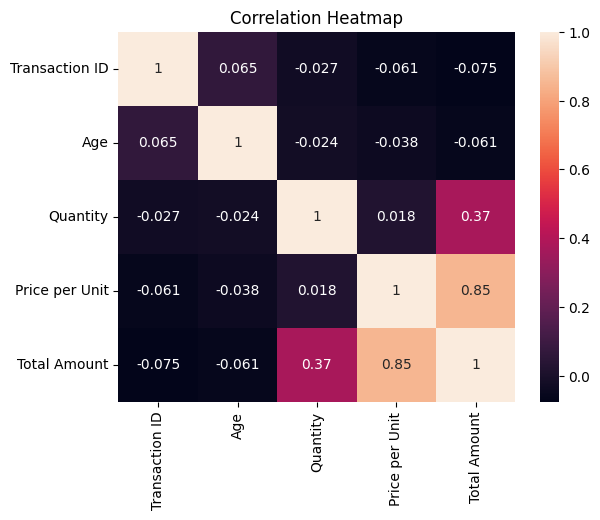

In [10]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Observation: Correlation Between Variables

- Some variables are positively related (increase together).
- Quantity and total amount show strong relationship.
- Price also affects total amount.

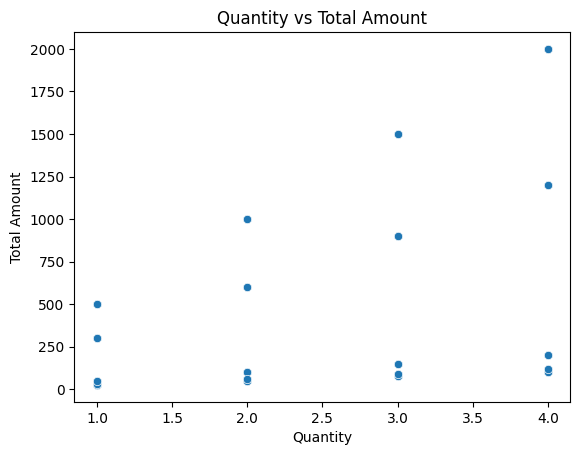

In [11]:
sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title("Quantity vs Total Amount")
plt.show()

# Observation: Quantity vs Total Amount

- As quantity increases, total amount also increases.
- There is a clear positive relationship between them.

# Final Conclusion

- Sales show seasonal trends with some peak months.
- Most customers are middle-aged individuals.
- Small purchases are more frequent than large ones.

# Business Recommendations:

1. Increase marketing and stock during peak months.
2. Focus on middle-aged customers for better targeting.
3. Promote offers like "Buy More, Save More" to increase quantity per purchase.